# books_with_summarized_review.csv 데이터 검증

- 데이터: `data/processed/books_with_summarized_review.csv`
- 목적: `pub_review_summarized` 컬럼 생성 결과 품질 검증

In [1]:
import platform
import pandas as pd
import matplotlib.pyplot as plt

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드

In [2]:
pd.set_option('display.max_colwidth', 80)

df = pd.read_csv('../data/processed/books_with_summarized_review.csv')
print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
print(f'컬럼 목록: {df.columns.tolist()}')
df.head(3)

레코드 수: 47,787
컬럼 수: 13
컬럼 목록: ['isbn', 'title', 'author', 'publisher', 'publish_date', 'page', 'book_intro', 'pub_review', 'cate_depth1', 'ori_cover_s', 'aladin_category_id', 'aladin_category_name', 'pub_review_summarized']


,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s,aladin_category_id,aladin_category_name,pub_review_summarized
0,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족은 떠날 채비를 한다. 국내 곳곳을 돌아다니며 아이들이...,산에 왜 갔지 ? 그 두 번째 이야기 준비 걸음 아빠 노릇 제대로 못했으니 봉사 한 번 해 주리라는 생각뿐. 첫 걸음 100개 산행을 목...,"['여행', '건강/취미']",https://image.aladin.co.kr/product/3917/39/cover500/8987835731_1.jpg,53529.0,국내도서>건강/취미>등산/캠핑,- 저자가 아이들과 함께 시작한 등산 여정을 담은 에세이임.\n\n- '첫 걸음'에서 백 개의 산행을 목표로 삼았으나 예상치 못한 변화와...
1,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 탄탄한 이야기, 끊임없는 상상력이 돋보이는 부요황후 ....","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다! 중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머...",['소설'],https://image.aladin.co.kr/product/24410/85/cover500/8963717712_1.jpg,51126.0,국내도서>소설/시/희곡>로맨스소설>외국 로맨스소설,"부요황후는 천하귀원 작가의 소설로, 2012년 진강시문예상과 전국우수여성문학상을 수상했으며 2018년 중국 드라마로 제작되어 큰 인기를..."
2,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",이희준 저,이야기나무,2015-07-07,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에 흩어진 435곳의 전통시장을 다니며 기록하면서 언제나...",전국에 흩어진 전통시장을 20대 청춘의 시선으로 기록하다! 공모전 준비와 스펙 쌓기에 바쁜 20대 청춘이 전통시장으로 향했다. 빨리 취업...,['여행'],https://image.aladin.co.kr/product/6266/95/cover500/k982433732_1.jpg,50846.0,국내도서>여행>국내 여행가이드>전국여행 가이드북,"- 20대 청춘이 전통시장을 방문하면서 느낀 점과 그 과정을 기록한 책이다. \n- 전국에 1,372개의 전통시장이 있고 서울에만 330..."


## 2. 결측값 현황

In [3]:
missing_df = pd.DataFrame({
    '결측 수': df.isnull().sum(),
    '결측률(%)': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('결측률(%)', ascending=False)

missing_df

,결측 수,결측률(%)
ori_cover_s,163,0.3
aladin_category_name,52,0.1
aladin_category_id,51,0.1
cate_depth1,38,0.1
isbn,0,0.0
publish_date,0,0.0
publisher,0,0.0
author,0,0.0
title,0,0.0
pub_review,0,0.0


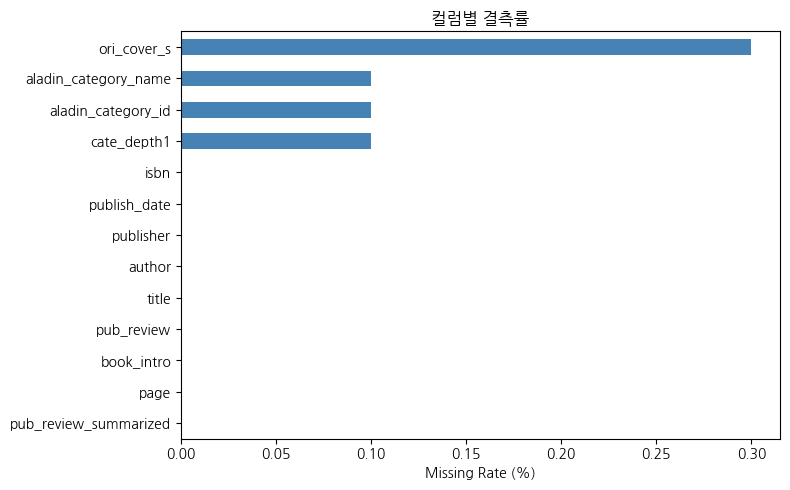

In [4]:
ax = missing_df['결측률(%)'].plot(kind='barh', figsize=(8, 5), color='steelblue')
ax.set_xlabel('Missing Rate (%)')
ax.set_title('컬럼별 결측률')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. pub_review_summarized 길이 분포

In [5]:
df['orig_len'] = df['pub_review'].str.len()
df['summ_len'] = df['pub_review_summarized'].str.len()
df['len_ratio'] = df['summ_len'] / df['orig_len']

print('=== pub_review (원본) 길이 통계 ===')
print(df['orig_len'].describe(percentiles=[.25, .5, .75, .95]).round(0))
print()
print('=== pub_review_summarized (요약) 길이 통계 ===')
print(df['summ_len'].describe(percentiles=[.25, .5, .75, .95]).round(0))
print()
print('=== 요약 비율 (summ / orig) 통계 ===')
print(df['len_ratio'].describe(percentiles=[.25, .5, .75, .95]).round(3))

=== pub_review (원본) 길이 통계 ===
count    47787.0
mean      1490.0
std       1360.0
min         10.0
25%        598.0
50%       1130.0
75%       1949.0
95%       3931.0
max      44108.0
Name: orig_len, dtype: float64

=== pub_review_summarized (요약) 길이 통계 ===
count    47787.0
mean       369.0
std        114.0
min         29.0
25%        287.0
50%        357.0
75%        437.0
95%        592.0
max        787.0
Name: summ_len, dtype: float64

=== 요약 비율 (summ / orig) 통계 ===
count    47787.000
mean         0.483
std          0.744
min          0.007
25%          0.199
50%          0.319
75%          0.535
95%          1.321
max         65.400
Name: len_ratio, dtype: float64


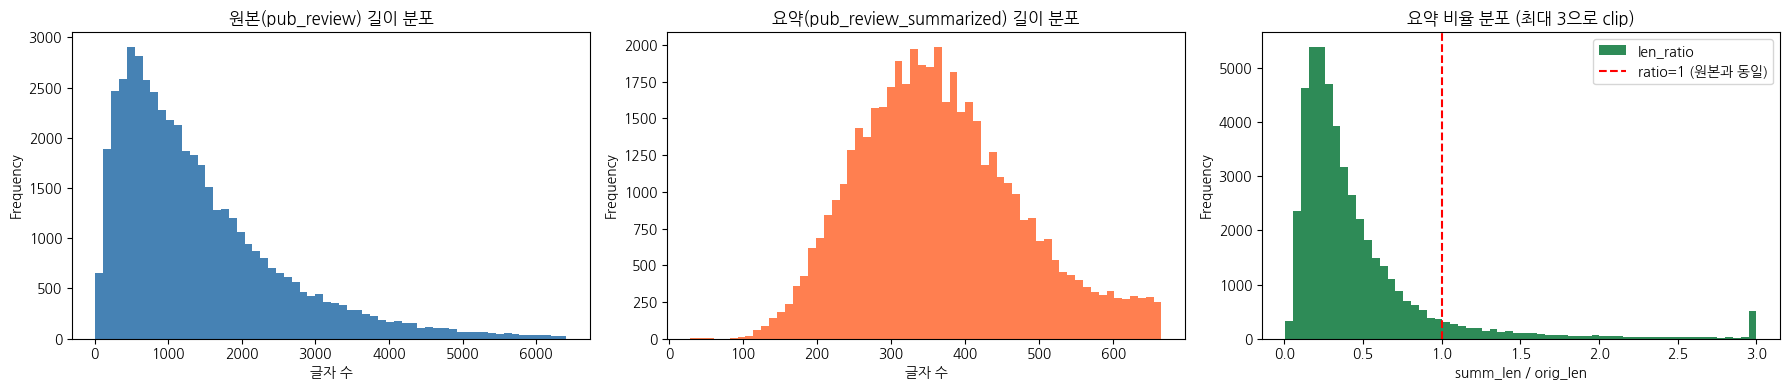

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

orig_p99 = df['orig_len'].quantile(0.99)
df[df['orig_len'] <= orig_p99]['orig_len'].plot(
    kind='hist', bins=60, ax=axes[0], color='steelblue'
)
axes[0].set_title('원본(pub_review) 길이 분포')
axes[0].set_xlabel('글자 수')

summ_p99 = df['summ_len'].quantile(0.99)
df[df['summ_len'] <= summ_p99]['summ_len'].plot(
    kind='hist', bins=60, ax=axes[1], color='coral'
)
axes[1].set_title('요약(pub_review_summarized) 길이 분포')
axes[1].set_xlabel('글자 수')

clip_ratio = df['len_ratio'].clip(upper=3)
clip_ratio.plot(kind='hist', bins=60, ax=axes[2], color='seagreen')
axes[2].set_title('요약 비율 분포 (최대 3으로 clip)')
axes[2].set_xlabel('summ_len / orig_len')
axes[2].axvline(1.0, color='red', linestyle='--', label='ratio=1 (원본과 동일)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. 이상 케이스 확인

In [7]:
# 카테고리별 이상 케이스 요약
cases = {
    '요약이 원본보다 긴 케이스 (ratio > 2)': (df['len_ratio'] > 2).sum(),
    '요약 길이 50자 미만': (df['summ_len'] < 50).sum(),
    '요약 길이 100자 미만': (df['summ_len'] < 100).sum(),
    '원본 길이 100자 미만': (df['orig_len'] < 100).sum(),
    '"서평 없음" 패턴 포함': df['pub_review_summarized'].str.contains('서평 없음|서평 정보|제공되지 않', na=False).sum(),
}
for k, v in cases.items():
    print(f'{k}: {v:,}건 ({v/len(df)*100:.1f}%)')

요약이 원본보다 긴 케이스 (ratio > 2): 1,129건 (2.4%)
요약 길이 50자 미만: 4건 (0.0%)
요약 길이 100자 미만: 20건 (0.0%)
원본 길이 100자 미만: 436건 (0.9%)
"서평 없음" 패턴 포함: 12건 (0.0%)


In [9]:
# 요약이 원본보다 훨씬 긴 케이스 (할루시네이션 가능성)
pd.set_option('display.max_colwidth', 200)
outliers = df[df['len_ratio'] > 2][['isbn', 'title', 'book_intro', 'pub_review', 'pub_review_summarized', 'orig_len', 'summ_len', 'len_ratio']]
print(f'요약이 원본의 2배 이상인 케이스: {len(outliers)}건')
outliers.sort_values('len_ratio', ascending=False).head(10)

요약이 원본의 2배 이상인 케이스: 1129건


,isbn,title,book_intro,pub_review,pub_review_summarized,orig_len,summ_len,len_ratio
23794,9791141902278,그곳의 바람을 만나다,어느 날 리프레쉬 휴가를 얻어 마음속에 자리 잡고 있던 그곳들을 여행하면서 지쳐가던 나를 보듬고 새로운 풍경과 만남 속에서 쌓인 무언가를 옮겼습니다.,북유럽 및 남미 편,"『세계테마기행 북유럽 & 남미 편』은 EBS 세계테마기행 제작진이 직접 발로 뛰어 촬영한 생생한 영상에 저자만의 통찰력 있는 해설을 더한 가이드북이다. 이 책은 총 3부로 구성되어 있으며 1부는 '꿈꾸는 동화 속 세상, 북유럽'이라는 주제로 노르웨이, 스웨덴, 핀란드 등 북유럽 국가들을 소개한다. 2부는 '태양의 후예들, 남미'라는 주제로 칠레, 아...",10,654,65.400000
16466,9788955450392,바흐 영국모음곡 1 - BWV 806-808,"피아노곡 1,600여작품을 103권의 원전악보 에 수록 (바흐부터 프로코피에프까지) 피아노 지상공개레슨 시리즈 는 242명의 국내 최정상 교수님들이 직접 레슨한 최고의 피아노작품집으로, 전국 각 대학 저명 교수님들의 다양한 최고 교수법을 직접 경험할 수 있다. 연주회에서조차 접하기 힘든 국내 최고 피아니스트들의 명 강의록이며 훌륭한 연주지도교재 로서...",레슨교수 김희옥 박규연,"서평: <나만의 특별한 레시피>\n\n이 책은 요리 초보자들을 위한 기본적인 요리 지식부터 고급 요리까지 다양한 요리 레시피를 담고 있다. 이 책에서는 한식, 중식, 양식 등 다양한 요리 스타일을 다루고 있으며, 각 요리에 대한 자세한 설명과 함께 필요한 재료와 조리 방법을 상세히 안내한다. \n\n특히, 저자들은 요리 과정에서 발생할 수 있는 실수...",12,386,32.166667
32946,9788955451337,리스트 6 - 사랑의 꿈. 발라드 제2번. 시적이고 종교적인 선율. 잊혀진 왈츠,"피아노곡 1,600여작품을 103권의 원전악보 에 수록 (바흐부터 프로코피에프까지) 피아노 지상공개레슨 시리즈 는 242명의 국내 최정상 교수님들이 직접 레슨한 최고의 피아노작품집으로, 전국 각 대학 저명 교수님들의 다양한 최고 교수법을 직접 경험할 수 있다. 연주회에서조차 접하기 힘든 국내 최고 피아니스트들의 명 강의록이며 훌륭한 연주지도교재 로서...",레슨교수 오진희 허정화 형희전,"레슨교수 오진희, 허정화, 형희전에 관한 출판사 서평은 다음과 같이 요약할 수 있습니다. \n\n- 이 책은 레슨교수 오진희, 허정화, 형희전이 쓴 음악교육서이다. \n- 저자들은 음악 교육이 학생들의 창의성과 예술적 감각을 발전시키는 데 중요하다고 강조한다. \n- 특히 피아노 연주와 작곡 등 다양한 음악 활동을 통해 학생들이 자신의 개성과 잠재...",16,358,22.375000
44409,9791137233416,손잡고 이탈,"48편의 시. 그리고 폴라로이드 사진들. 사랑하는 이의 손을 잡고 있을 때 더 자유롭고 싶은 마음, 더 자유로워지는 마음을 모두 담았다.",사진 문중주 스스로 사진관 자아성촬 디렉터,이 책은 평범한 사람들의 특별한 순간을 기록해 주는 사진 문중주의 이야기다. 그는 자신만의 독특한 시각으로 인물들을 촬영하며 이 과정에서 서로의 관계와 감정을 더욱 깊게 이해할 수 있도록 돕는다. \n\n문중주는 단순히 사진을 찍는 것이 아니라 '자아 성찰'이라는 새로운 개념을 제시한다. 이를 통해 고객들은 자신의 내면을 탐구하고 더 나은 방향으로 ...,23,475,20.652174
39647,9791138404853,현자의 제자를 자칭하는 현자 15 = 賢者の弟子を名?る賢者 15,"나, 당신의 정체, 알아냈다해. 플레이어가 건국한 니르바나 황국에서 열리는 투기대회. 그것은 대륙중의 강자가 모이는 일대 이벤트이다. 강적을 찾아 여행을 계속하는 메이린이라면 반드시 참가할 것이라고 믿는 미라는 수도 라트나트라야로 향하게 된다. 새로운 의상을 입은 미라는 마리아나, 반려동물 루나와의 치유 시간을 마치고, 새로운 모험을 떠난다. 하지만...",2022년 1월 애니메이션 방영!,<귀멸의 칼날> 원작 23권 분량까지의 스토리를 담은 극장판 <귀멸의 칼날: 무한열차편>이 2022년 1월 개봉 예정이다. 이 작품은 다이쇼 시대를 배경으로 도깨비에게 가족을 잃은 주인공 탄지로가 귀살대에 들어가 도깨비와 싸우는 이야기다. \n\n이번 영화에서는 열차 안에서 벌어지는 전투 장면이 중점적으로 다뤄지며 화려한 액션신과 함께 감동적인 이...,18,358,19.888889
9114,9788955450149,"베토벤 피아노 소나타집 4 - Nos. 16,17,18,19,20","피아노곡 1,600여작품을 103권의 원전악보 에 수록 (바흐부터 프로코피에프까지) 피아노 지상공개레슨 시리즈 는 242명의 국내 최정상 교수님들이 직접 레슨한 최고의 피아노작품집으로, 전국 각 대학 저명 교수님들의 다양한 최고 교수법을 직접 경험할 수 있다. 연주회에서조차 접하기 힘든 국내 최고 피아니스트들의 명 강의록이며 훌륭한 연주지도교재 로서...",레슨교수 장혜원 이혜경 전영혜 김 석 박진희,"서평: <나만의 컬러 찾기>\n\n이 책은 색채 심리학을 바탕으로 자신에게 맞는 컬러를 찾는 방법을 알려주는 자기 계발서이다. 저자들은 각각 미술교육학과 교수, 색채심리상담사, 패션디자이너 등 다양한 분야에서 활동하며 쌓아온 경험을 바탕으로 이 책을 집필하였다. \n\n책에서는 먼저 우리 주변에 있는 다양한 색상들과 그 색상들이 가지는 의미와 상징성...",24,469,19.541667
10971,8809507024500,NEW 동물가족화 카드,"가족 구성원을 비록한 친구, 동료 등의 다양한 대상들에 대한 자신의 주관적 정서를 동물에 투사하여 드러냄으로써 관계의 역동을 탐색하는 데 유용한 카드이다.","목적 -대상의 성격, 정서, 상호 관계의 역동성 탐색","서평 : ""관계의 힘""\n\n이 책은 인간 사이의 다양한 관계에서 발생하는 감정과 행동에 대한 이야기를 담고 있다. 저자는 사람들이 서로 어떻게 영향을 주고받는지, 그리고 그 과정에서 어떤 일이 일어나는지 탐구하며, 이를 통해 우리가 더 나은 관계를 형성하고 유지하는 방법을 제시한다.\n\n책에서는 가족, 친구, 동료 등 다양한 대상과의 관계에서 나...",29,556,19.172414
28186,9788955450163,"베토벤 피아노 소나타집 6 - Nos.28,29,30,31,32","피아노곡 1,600여작품을 103권의 원전악보 에 수록 (바흐부터 프로코피에프까지) 피아노 지상공개레슨 시리즈 는 242명의 국내 최정상 교수님들이 직접 레슨한 최고의 피아노작품집으로, 전국 각 대학 저명 교수님들의 다양한 최고 교수법을 직접 경험할 수 있다. 연주회에서조차 접하기 힘든 국내 최고 피아니스트들의 명 강의록이며 훌륭한 연주지도교재 로서...",레슨교수 현재희 한희철 고중원 임옥빈 강성애,"서평: <세계시민교육>\n\n* 이 책은 세계시민교육에 관심 있는 교사와 교육전문가들을 위한 지침서로, 세계시민교육의 개념과 목표, 방법 등을 제시하며 실제 수업에서 활용할 수 있는 다양한 활동 예시를 담고 있다.\n\n* 저자들은 세계시민교육이 단순히 국제사회 문제를 다루는 것이 아니라 개인의 가치관과 태도를 변화시켜 글로벌 시민으로 성장하도록 돕...",24,449,18.708333
41175,9791160034455,잃어버린 꿈에 피는 꽃,오랫동안 잃어버린 꿈에서도 꽃을 피울 수 있음을 노래하고 싶어서.,사파일지언정 참에 이르를 수 있음을 노래하다.,『참 나를 찾는 길』은 저자가 20여 년간 집필해 온 인문학적 사유와 철학이 담긴 작품이다. 이 책은 삶의 본질을 탐구하며 인간 존재의 의미를 찾아가는 여정을 담고 있다. \n\n삶의 근본적인 물음에 대한 답을 찾기 위해 다양한 분야의 지식을 섭렵했고 그 과정에서 얻은 깨달음을 바탕으로 자신만의 독특한 세계관을 형성했다. 이러한 사상을 통해 우리에게...,25,435,17.400000
43899,9788955451603,라벨 1 - 거울·고귀하고 감상적인 왈츠·물의 유희·고풍스런

In [10]:
# 짧은 요약 케이스 상세 확인
short_summ = df[df['summ_len'] < 50][['isbn', 'title', 'pub_review', 'pub_review_summarized', 'orig_len', 'summ_len']]
print(f'요약 50자 미만: {len(short_summ)}건')
short_summ

요약 50자 미만: 4건


,isbn,title,pub_review,pub_review_summarized,orig_len,summ_len
14829,9788955450217,쇼팽 연습곡 작품25 - 12 Etudes Opus25,레슨교수 채준자 조연하 김성신 나광자 강중수 김순화,서평 없음. 해당 출판사의 서평이 존재하지 않습니다.,28,29
34269,9791168180796,2023 김재운 캐칭 영어 세트,동영상 강의 www.wowedu.co.kr www.ustudy.co.kr,서평 텍스트가 제공되지 않았습니다. 해당 정보를 바탕으로 한 서평 요약은 어렵습니다.,40,47
37233,9791167621221,남프랑스 홀리데이 - 의 휴가를 위한 여행 파우치 홀리데이 시리즈,"니스, 아를, 깐느, 액상프로방스 남프랑스 소도시 14곳에 대한 상세 가이드! 한층 새롭고 다채로워진 남프랑스 홀리데이 2025 2026 최신 개정판! 남프랑스 소도시 여행의 첫걸음이자, 첫사랑 같은 책 개성 넘치는 남프랑스 소도시를 구석구석 짜임새 있게 소개한다 남프랑스는 대서양과 지중해, 스페인과 이탈리아와 맞닿아 있어 다양한 자연환경과 여러 문...",천하는 인기 숙소도 함께 소개하여 선택의 폭을 넓혔다.,4428,30
39430,9788955451634,프로코피에프 2 - 피아노 소나타,레슨교수 김경리 유소영,서평 정보가 없습니다. 대상 도서를 알려주시면 서평을 요약해 드릴 수 있습니다.,12,44


In [11]:
# 원본이 짧은 경우 (100자 미만) 요약 품질 확인
short_orig = df[df['orig_len'] < 100][['isbn', 'title', 'pub_review', 'pub_review_summarized', 'orig_len', 'summ_len', 'len_ratio']]
print(f'원본 100자 미만: {len(short_orig)}건')
short_orig.head(10)

원본 100자 미만: 436건


,isbn,title,pub_review,pub_review_summarized,orig_len,summ_len,len_ratio
76,9791125700821,"박학다식 시사일반상식 - 2016,공사/공단/언론사/기업체 입사대비",특 징 중요 주제를 엄선하여 정리 꼭 알아야 하는 알짜 상식을 영역별로 엄선 공사 공단 기업체 등 실제 출시된 상식 기출유형문제 논술 작성법과 논술 작성의 예시 수록,"- 이 책은 취업 준비생들을 위한 최신 출제 경향에 맞춘 상식 기출 문제와 다양한 분야의 지식을 담고 있다.\n\n- 각 장마다 중요한 주제를 선별하여 체계적으로 구성되어 있으며, 필수적인 상식만을 담아 효율적인 학습이 가능하다. \n\n- 경제, 사회, 문화, 정치, 과학기술 등 여러 영역에서 필요한 정보를 얻을 수 있고, 실제 공사 공단이나 기...",92,289,3.141304
286,9791166330544,2021 독학사 2단계 생산운영관리 - 21 합격예감 독학사 2단계,2020 2019년 기출문제 완벽 복원 수록! 최신 출제경향에 맞춘 핵심 이론 정리 기출유형 다잡기 합격 TEST 2회 수록,"이 책은 2020년과 2019년의 기출문제를 완벽하게 복원하여 수록하였습니다. 또한 최근 출제 경향에 맞춰 핵심 이론을 정리하였고, 기출 유형을 파악할 수 있는 '다잡기 합격 TEST'를 2회분 제공합니다. \n\n컴퓨터 활용능력 자격증을 준비하는 초보자부터 중급 수준의 학습자까지 모두에게 도움이 될 것입니다.",69,173,2.507246
519,9788996582953,독학사 마케팅 조사 - 경영학과 2단계,"마케팅 조사는 각종 통계방법과 공식, 복잡한 분석 도구들에 대한 깊이있는 이해가 필요한 과목입니다. 나무독학사교육원 김진구 교수님의 강의와 교재로 차근차근 준비하세요.",- 이 책은 독학사 마케팅조사 과정을 준비하는 수험생을 위한 것이다. \n- 김진구 저자의 노하우를 바탕으로 기출문제를 철저히 분석하여 시험에 꼭 나오는 문제들을 엄선했다. \n- 각 장마다 출제 경향을 파악할 수 있는 출제 예상문제를 수록하였다. \n- 이론 설명 후 바로 확인 가능한 OX 퀴즈를 통해 학습한 내용을 한 번 더 복습할 수 있다. \...,93,224,2.408602
649,9791138373241,2025 시대에듀 감정평가사 1차 회계학 기출문제집(+최종모의고사),- 감정평가사 1차 회계학 9개년 기출문제 정답 및 해설 회계학 최종모의고사 2회분 최종모의고사 정답 및 해설 수록 - 쉽게 이해할 수 있는 상세한 해설 수록,"이 책은 감정평가사 1차 시험을 준비하는 수험생들을 위한 회계학 기출문제집이다. 최근 9개년 동안 출제된 문제들을 모두 수록하였으며, 각 문제에 대한 상세한 해설을 함께 제공한다. 이를 통해 수험생들은 문제를 푸는 과정에서 필요한 이론적인 지식을 습득하고, 자신이 부족한 부분을 파악하여 보완할 수 있다. 또한, 추가로 2회의 최종 모의고사와 그에 대...",88,302,3.431818
717,9791192520377,항공정비사 면허 종합문제 및 해설,유튜브 무료동영상 강의 ABC항공정비메카 https www.youtube.com channel UC2Xr8fYnQMUNFsh89-7ImLA,이 책은 항공 정비에 관심 있는 사람들을 위한 유튜브 채널 'ABC 항공정비 메카'의 무료 동영상 강의를 정리한 것이다. 이 책은 항공 정비 분야에서 필요한 기초 지식부터 심화 지식까지 다양한 내용을 다루고 있다. 저자는 항공 정비사가 되기 위해 필요한 자격증 취득 방법과 함께 실제 현장에서 활용할 수 있는 실무 지식도 함께 전달한다. \n\n책에서...,77,433,5.623377
744,9791125963158,시작은 하루 수능 수학2 기초 (2024년용) - 수능 (2023년),1) 쉽고 재미있고 빠르게 익히는 수능 기초 교재 2) 난이도를 낮춘 문제로 성취감과 자신감을 주는 교재 3) 수능과 내신을 모두 대비할 수 있는 교재,- 이 책은 어려운 수능 기초를 쉽고 재미있게 익힐 수 있도록 구성되었다. \n- 쉬운 난이도로 시작해 단계적으로 높여가며 성취감과 자신감을 얻을 수 있다. \n- 수능뿐만 아니라 내신까지 동시에 대비 가능하다. \n- 다양한 유형의 문제와 자세한 해설이 포함되어 있어 혼자서도 충분히 학습할 수 있다. \n- 처음 수능을 접하는 학생부터 심화 학습이...,84,212,2.523810
1320,9788964490235,명리서경,기초 이론에서 실전 통변까지 핵심 지침서 바른 이름 짓기 성명학 수록 통변법 사례(종합 감정) 수록,"이 책은 사주팔자 명리학에 대한 기초 이론부터 실전 통변까지 상세히 알려주는 지침서로, 저자가 오랜 시간 연구해 온 성명학도 함께 수록되어 있다. 이 책에서는 종합 감정 방법 및 실제 사주팔자 예시를 통해 구체적인 통변법을 제시하며, 이를 통해 독자들은 자신의 사주팔자를 정확하게 분석하고 미래를 예측할 수 있게 된다. 따라서 명리학 초보자부터 전문가...",55,221,4.018182
1453,9788994723594,2021 정상 해사법규 객관식 - 해양경찰 승진·채용합격대비,- 독자대상 해양 경찰 승진 채용 시험 준비생 - 구성 및 특징 1. 최근 법령 완벽반영 2. 최근 8년간 기출문제 석 3. 출제예상핵심문제,"해양 경찰 승진 채용 시험 준비생을 위한 본서는 최신 법령을 완벽하게 반영하였으며, 최근 8년간 기출문제를 수록하였습니다. 또한 출제 예상 핵심 문제를 통해 시험에 대비할 수 있도록 구성되었습니다.",78,110,1.410256
1640,8809854312299,먼작귀 스케줄스티커 : 먼작귀 친구들 - 귀 스케줄 스티커,"모몽가, 랏코, 쿠리만쥬, 시사 등 개성이 넘치는 친구들의 9가지 테마별 활약을 담았어요.","『동물의 숲 포켓 캠프』 속 인기 캐릭터들이 펼치는 다양한 이야기를 담은 만화로, 모몽가, 랏코, 쿠리만쥬, 시사 등 개성 넘치는 친구들의 9가지 테마별 활약을 담았습니다. 게임 내에서만 즐길 수 있었던 특별한 에피소드들을 만나볼 수 있어요. 닌텐도 스위치 유저라면 누구나 공감할 만한 일상적인 이야기와 함께 귀여운 일러스트도 감상할 수 있습니다.",50,194,3.880000
2031,8809666650145,키난빌 페이퍼토이 공룡 만들기,다양한 공룡을 스스로 만들며 성취감과 집중력을 기를 수 있으며 자유롭게 표현하며 상상력을 키워줍니다.,이 책은 다양한 공룡을 직접 만들며 아이들에게 성취감과 집중력을 길러주는 것을 목적으로 합니다. 이 책은 종이접기처럼 쉽게 따라 할 수 있는 설명서와 함께 여러 가지 공룡 도안을 제공하여 아이들이 자신만의 창의적인 디자인으로 원하는 공룡을 만들 수 있도록 도와줍니다. 또한 각 페이지마다 간단한 설명과 팁이 있어 초보자도 쉽게 따라 할 수 있습니다. ...,56,344,6.142857


## 5. 요약 품질 샘플 확인

In [12]:
# 정상 케이스 랜덤 샘플 (ratio 0.2 ~ 0.6)
normal = df[(df['len_ratio'] >= 0.2) & (df['len_ratio'] <= 0.6)].sample(5, random_state=42)

for _, row in normal.iterrows():
    print(f"[{row['title']}] (원본 {row['orig_len']:.0f}자 → 요약 {row['summ_len']:.0f}자, ratio={row['len_ratio']:.2f})")
    print(f"  원본: {row['pub_review'][:150]}...")
    print(f"  요약: {row['pub_review_summarized'][:200]}")
    print()

[아트 어드벤처 2 - 다 빈치와 최후의 만찬] (원본 943자 → 요약 367자, ratio=0.39)
  원본: 어렵고 따분한 예술은 가라! 신나게 즐기는 예술 학습만화 아트 어드벤처 , 그 두 번째 이야기 아이들은 예술을 어렵고 재미없는 것이라고 생각하기 쉽습니다. 사실 어른들도 예술 작품을 감상하고 이해하는 일을 매우 곤혹스러워 합니다. 하지만 예술이 이 세상에서 사라진다면 ...
  요약: 아트 어드벤처 시리즈는 아이들이 예술을 쉽고 재미있게 즐길 수 있도록 안내하는 학습만화이다.  '다 빈치와 최후의 만찬' 편에서는 예술작품을 소멸시키려는 반예술단체 AAA와 이를 막기 위한 AS 센터의 대결을 그리고 있다. 주인공들은 레오나르도 다 빈치의 작품세계를 탐험하며 그의 열정과 노력을 배우고, 다양한 예술 작품을 감상하면서 예술의 가치와 의미를 깨

[뽀득뽀득 손을 씻어요 - 심과 함께하는 안전이야기 4] (원본 1945자 → 요약 454자, ratio=0.23)
  원본: 또조심과 함께하는 안전이야기 그림책 시리즈는 어린이들에게 반드시 필요한 생활안전지침을 또래 친구들이 벌이는 재미난 이야기를 통해 보여 줍니다. 유치원과 친구, 나와 가족, 우리 동네, 건강과 안전 등 누리과정의 생활주제로 나눠 생활안전, 신변안전, 교통안전, 소방안전,...
  요약: '또조심과 함께하는 안전이야기' 그림책 시리즈는 유아들을 대상으로 한 안전 지침서다. 해당 시리즈는 누리과정의 생활주제를 기반으로 하며, 생활안전, 신변안전, 교통안전, 소방안전, 재난/재해 대비안전, 식품/약물안전 등 다양한 안전 영역을 다룬다.  각각의 권에는 2-3개의 짧은 에피소드가 포함되어 있으며, 이를 통해 어린이들은 실생활에서 마주할 수 있는 

[정재승의 인간 탐구 보고서 14 - 인간, 돈의 유혹에 퐁당 빠지다] (원본 1122자 → 요약 273자, ratio=0.24)
  원본: 인간을 탐구하기 위해 외계인들이 도착했다! 외계인의 눈에 비친 우리는 과연 어떤 모습일까? 머나먼 행성 아우레

## 6. 카테고리별 요약 길이 분포

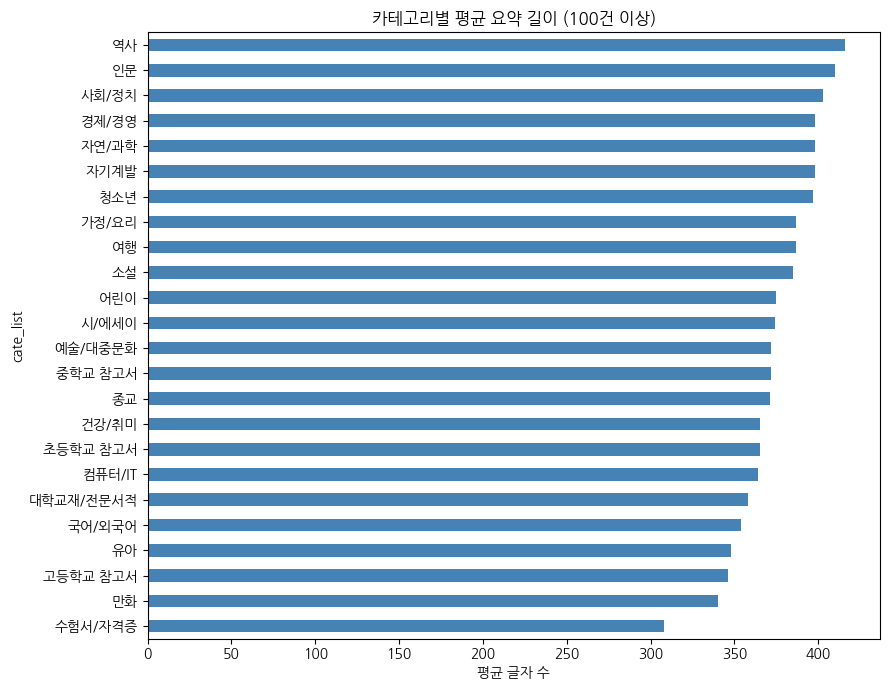

,평균 요약 길이,건수
cate_list,,
역사,416.0,1599
인문,410.0,3117
사회/정치,403.0,3020
경제/경영,398.0,3183
자연/과학,398.0,1202
자기계발,398.0,2261
청소년,397.0,1501
가정/요리,387.0,1289
여행,387.0,902


In [13]:
import ast

def parse_cate(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val) if isinstance(val, str) else val
    except Exception:
        return [val]

df_cate = df.copy()
df_cate['cate_list'] = df_cate['cate_depth1'].apply(parse_cate)
df_exploded = df_cate.explode('cate_list').dropna(subset=['cate_list'])
df_exploded = df_exploded[df_exploded['cate_list'].str.strip() != '']

cate_stats = df_exploded.groupby('cate_list')['summ_len'].agg(['mean', 'count']).round(0)
cate_stats.columns = ['평균 요약 길이', '건수']
cate_stats = cate_stats[cate_stats['건수'] >= 100].sort_values('평균 요약 길이', ascending=False)

ax = cate_stats['평균 요약 길이'].plot(kind='barh', figsize=(9, 7), color='steelblue')
ax.set_title('카테고리별 평균 요약 길이 (100건 이상)')
ax.set_xlabel('평균 글자 수')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

cate_stats

## 7. 전체 품질 요약

In [14]:
total = len(df)
normal_cnt = ((df['len_ratio'] >= 0.1) & (df['len_ratio'] <= 2.0)).sum()
hallucination_cnt = (df['len_ratio'] > 2).sum()
no_review_cnt = df['pub_review_summarized'].str.contains('서평 없음|서평 정보|제공되지 않', na=False).sum()
short_summ_cnt = (df['summ_len'] < 50).sum()

print('===== 전체 품질 요약 =====')
print(f'총 레코드 수         : {total:>8,}건')
print(f'정상 범위 요약        : {normal_cnt:>8,}건 ({normal_cnt/total*100:.1f}%)')
print(f'할루시네이션 의심 (ratio>2): {hallucination_cnt:>8,}건 ({hallucination_cnt/total*100:.1f}%)')
print(f'"서평 없음" 처리      : {no_review_cnt:>8,}건 ({no_review_cnt/total*100:.1f}%)')
print(f'요약 50자 미만        : {short_summ_cnt:>8,}건 ({short_summ_cnt/total*100:.1f}%)')
print()
print(f'평균 원본 길이: {df["orig_len"].mean():.0f}자')
print(f'평균 요약 길이: {df["summ_len"].mean():.0f}자')
print(f'평균 압축률:   {df["len_ratio"].median():.1%} (중앙값 기준)')

===== 전체 품질 요약 =====
총 레코드 수         :   47,787건
정상 범위 요약        :   44,466건 (93.1%)
할루시네이션 의심 (ratio>2):    1,129건 (2.4%)
"서평 없음" 처리      :       12건 (0.0%)
요약 50자 미만        :        4건 (0.0%)

평균 원본 길이: 1490자
평균 요약 길이: 369자
평균 압축률:   31.9% (중앙값 기준)
